<a href="https://colab.research.google.com/github/guupiii/ESAA/blob/main/ESAA_OB_week9_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**5.2 합성곱 신경망 맛보기**

In [17]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision. transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch.device( "cuda:0" if torch.cuda.is_available() else "cpu" )

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train_dataset = torchvision.datasets.FashionMNIST( "/content/drive/MyDrive/MLData" , download=True,
transform=transforms. Compose( [transforms . ToTensor()] ))
test_dataset = torchvision.datasets.FashionMNIST( "/content/drive/MyDrive/MLData" , download=True ,
train=False, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.40MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 157kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.3MB/s]


In [5]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

torch.utils.data.DataLoader()를 사용하여 원하는 크기의 배치 단위로 데이터를 불러오거나, 순서가 무작위로 섞이도록 할 수 있다.



In [7]:
import numpy as np

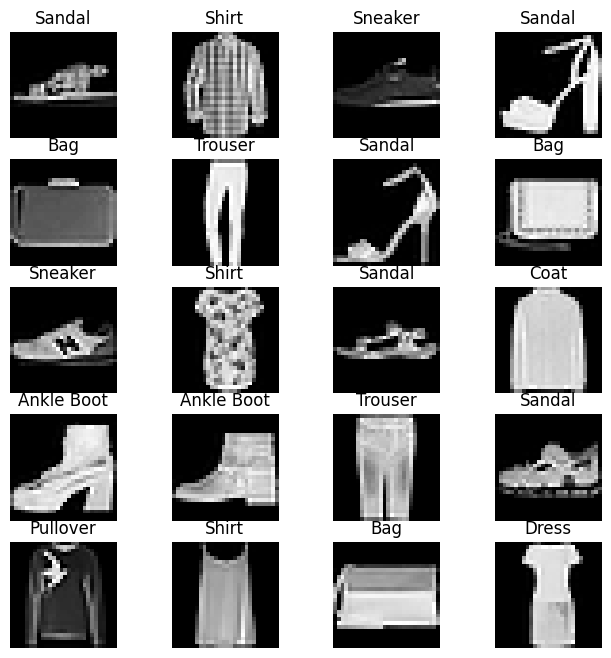

In [8]:
labels_map = { 0 : 'T-Shirt', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress', 4: 'Coat', 5 : 'Sandal', 6 : 'Shirt', 7 : 'Sneaker', 8 : 'Bag' , 9 : 'Ankle Boot' }

fig = plt.figure( figsize=(8,8));
columns = 4;
rows = 5;
for i in range(1, columns*rows +1):
    img_xy = np.random.randint(len(train_dataset));
    img = train_dataset[img_xy][0][0, :, :]
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()

np.random 은 무작위로 데이터를 생성할 때 사용한다. 또한, np.random.randint()는 이산형 분포를 갖는 데이터에서 무작위 표본을 추출할 때 사용한다.

참고로 random.randint와 유사하게 사용되는 random.rand와 random.randn이 있다.



In [9]:
class FashionDNN (nn .Module ):
    def __init__ (self):
        super(FashionDNN , self). __init__()
        self.fc1 = nn.Linear(in_features=784, out_features=256)
        self.drop = nn.Dropout(0.25)
        self.fc2 = nn.Linear(in_features=256, out_features=128 )
        self.fc3 = nn.Linear(in_features=128, out_features=10)
    def forward (self ,input_data):
        out = input_data. view (-1 ,784)
        out = F.relu(self.fc1(out))
        out = self.drop(out)
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out

클래스 형태의 모델은 항상 torch.nn.Module을 상속받는다. __init__()은 객체가 갖는 속성 값을 초기화하는 역할을 하며, 객체가 생성될 때 자동으로 호출된다.

객체 지향 프로그래밍은 프로그래밍에서 필요한 데이터를 추상화하여 속성이나 행동, 동작, 특징 등을 객체로 만들고 그 객체들이 서로 유기적으로 동작하도록 하는 프로그래밍 방법이다.

그리고 객체란 메모리를 할당받아 프로그램에서 사용되는 모든 데이터를 의미하기 때문에 변수, 함수 등은 모두 객체라고 할 수 있다.

함수란 하나의 특정 작업을 수행하기 위해 독립적으로 설계된 프로그램 코드이다. 함수의 호출은 특정 자겁만 수행할 뿐 아니라 그 결괏값을 계속 사용하기 위해서는 반드시 어딘가에 따로 그 값을 지정해야만 한다. 즉, 함수를 포함한 프로그램 코드이 일부를 재사용하기 위해서는 해당 함수뿐만아니라 데이터가 저장되는 변수까지도 한꺼번에 관리해야 한다.



nn은 딥러닝 모델 구성에 필요한 모듈이 모여 있는 패키지이며, Linear는 단순 선형 회귀 모델을 만들 때 사용한다.

forward() 함수는 모델이 학습 데이터를 입력받아서 순전파 학습을 진행시키며, 반드시 forward라는 이름의 함수여야 한다. 즉 forward()는 모델이 학습 데이터를 입력받아서 순전파 연산을 진행하는 함수이며, 객체를 데이터와 함께 호출하면 자동으로 실행된다.


파이토치에서 사용하는 뷰는 넘파이의 reshape와 같은 역할로 텐서의 크기를 변경해주는 역할을 한다.

In [10]:
learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


옵티마이저를 위한 경사 하강법은 Adam을 사용하며, 학습률을 의미하는 lr는 0.001.을 사용한다는 의미이다.



In [14]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []
predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)
        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))



Iteration: 500, Loss: 0.5585971474647522, Accuracy: 83.13999938964844%
Iteration: 1000, Loss: 0.5245999097824097, Accuracy: 83.83000183105469%
Iteration: 1500, Loss: 0.33163005113601685, Accuracy: 84.30000305175781%
Iteration: 2000, Loss: 0.40930983424186707, Accuracy: 85.52999877929688%
Iteration: 2500, Loss: 0.253914475440979, Accuracy: 86.30000305175781%
Iteration: 3000, Loss: 0.3368028700351715, Accuracy: 87.05000305175781%


모델이 데이터를 처리하기 위해서는 모델과 데이터가 동일한 장치에 있어야 한다. 참고로 cpu에서 처리된 데이터를 gpu 모델에 적용하거나 그 반대의 경우 런타임 오류가 발생한다.

Autograd는 자동 미분을 수행하는 파이토치의 핵심 패키지로, 자동 미분에 대한 값을 저장하기 위해 테이프를 사용한다. 순전파 단계에서 테이프는 수행하는 모든 연산을 저장한다. 그리고 역전파 단계에서 저장된 값들을 꺼내서 사용한다.

분류 문제에 대한 정확도는 전체 예측에 대한 정확한 예측의 비율로 표현할 수 있다.



In [29]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

MaxPool2d는 이미지 크기를 축소시키는 용도로 사용한다. 풀링 계층은 합성곱층의 출력 데이터를 입력으로 받아서 출력 데이터의 크기를 줄이거나 특정 데이터를 강조하는 용도로 사용된다.

클래스를 분류하기 위해서는 이미지 형태의 데이터를 배열 형태로 변환하여 작업해야 한다.
이때 conv2d에서 사용하는 하이퍼파라미터 값들에 따라 출력 크기가 달라진다.



**Conv2d 계층에서의 출력 크기 구하는 공식**

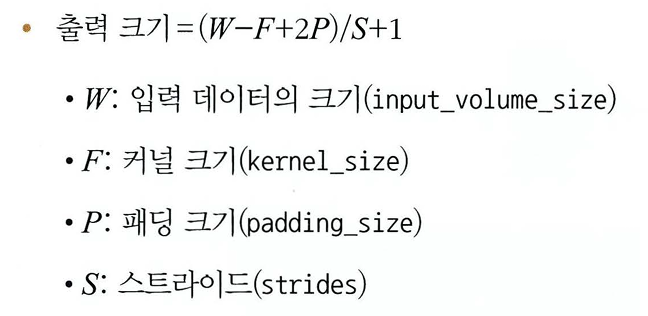

**MaxPool2d 계층에서의 출력 크기 구하는 공식**

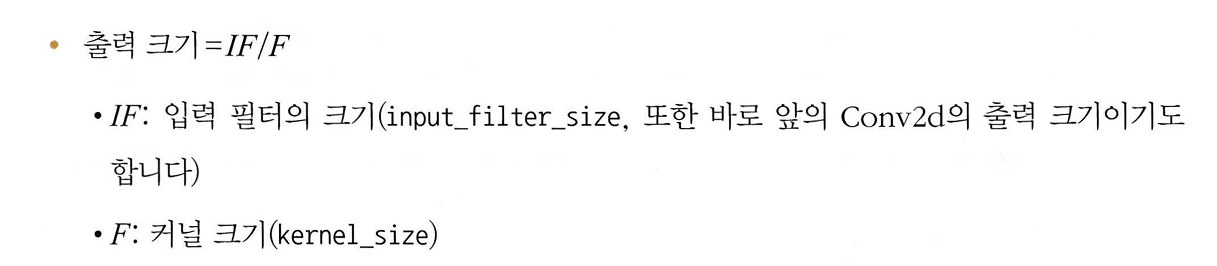

In [30]:
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [31]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total = 0
            correct = 0
            for imagesd, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format
                  (count, loss.data, accuracy))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration: 500, Loss: 0.46901699900627136, Accuracy: 10.510000228881836%
Iteration: 1000, Loss: 0.33105090260505676, Accuracy: 9.720000267028809%
Iteration: 1500, Loss: 0.2752050459384918, Accuracy: 10.510000228881836%
Iteration: 2000, Loss: 0.21554286777973175, Accuracy: 9.619999885559082%
Iteration: 2500, Loss: 0.1307479441165924, Accuracy: 10.210000038146973%
Iteration: 3000, Loss: 0.19734124839305878, Accuracy: 10.65999984741211%


심층 신경망과 비교하여 정확도가 약간 높다. 심층 신경망과 별 차이가 없기 때문에 조 먿 간편한 심층 신경망만 사용해도 무난할 것 같지만 실제로 이미지 데이터가 많아지면 단순 심층 신경망으로는 정확한 특성 추출 및 분류가 불가능하므로 합성곱 신경망을 생성할 수 있도록 학습해야 한다.